# 17 · Natural Language Processing (NLP)

**Difficulty:** Intermediate-Advanced | **Time:** ~3 hours

## Table of Contents
1. Text Preprocessing Pipeline
2. Bag of Words & TF-IDF
3. Word Embeddings (Word2Vec concept)
4. Sentiment Analysis
5. Text Classification
6. Topic Modeling (LDA)
7. Real-World: News Article Classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from collections import Counter
import re, string
warnings_imported = True
import warnings
warnings.filterwarnings('ignore')
print('Ready ✓')

Ready ✓


## 1. Text Preprocessing

In [2]:
# Common text preprocessing steps
RAW_TEXT = [
    'The Quick Brown Fox Jumps Over the Lazy Dog!!',
    'Python is AMAZING for Data Science :)',
    'Machine Learning is the FUTURE... no doubt!',
    'I LOVE Natural Language Processing (NLP)',
    'Text preprocessing is VERY important...'
]

def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Remove extra whitespace
    text = ' '.join(text.split())
    return text

STOPWORDS = {'the','is','are','was','were','be','been','a','an','and',
              'or','but','in','on','at','to','for','of','with','by','from',
              'this','that','it','i','you','he','she','we','they','very'}

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOPWORDS)

def stem_simple(word):
    suffixes = ['ing','ed','tion','ness','ment','ful','able','ible','ly']
    for suf in suffixes:
        if word.endswith(suf) and len(word) > len(suf)+2:
            return word[:-len(suf)]
    return word

def full_pipeline(text):
    text = preprocess(text)
    text = remove_stopwords(text)
    text = ' '.join(stem_simple(w) for w in text.split())
    return text

print('Text Preprocessing Pipeline:')
for raw in RAW_TEXT:
    print(f'  RAW    : {raw}')
    print(f'  CLEAN  : {full_pipeline(raw)}')
    print()

Text Preprocessing Pipeline:
  RAW    : The Quick Brown Fox Jumps Over the Lazy Dog!!
  CLEAN  : quick brown fox jumps over lazy dog

  RAW    : Python is AMAZING for Data Science :)
  CLEAN  : python amaz data science

  RAW    : Machine Learning is the FUTURE... no doubt!
  CLEAN  : machine learn future no doubt

  RAW    : I LOVE Natural Language Processing (NLP)
  CLEAN  : love natural language process nlp

  RAW    : Text preprocessing is VERY important...
  CLEAN  : text preprocess important



## 2. Bag of Words & TF-IDF

In [3]:
# Bag of Words
docs = [
    'I love machine learning and data science',
    'Data science is great for business insights',
    'Machine learning models need lots of data',
    'Deep learning is a subset of machine learning',
]

# CountVectorizer
cv = CountVectorizer()
bow = cv.fit_transform(docs)
bow_df = pd.DataFrame(bow.toarray(), columns=cv.get_feature_names_out())
print('Bag of Words:')
print(bow_df.to_string())

# TF-IDF — gives more weight to rare, important words
tfidf = TfidfVectorizer()
tf = tfidf.fit_transform(docs)
tf_df = pd.DataFrame(tf.toarray().round(3), columns=tfidf.get_feature_names_out())
print('\nTF-IDF Matrix:')
print(tf_df.to_string())

Bag of Words:
   and  business  data  deep  for  great  insights  is  learning  lots  love  machine  models  need  of  science  subset
0    1         0     1     0    0      0         0   0         1     0     1        1       0     0   0        1       0
1    0         1     1     0    1      1         1   1         0     0     0        0       0     0   0        1       0
2    0         0     1     0    0      0         0   0         1     1     0        1       1     1   1        0       0
3    0         0     0     1    0      0         0   1         2     0     0        1       0     0   1        0       1

TF-IDF Matrix:
    and  business   data   deep    for  great  insights     is  learning   lots  love  machine  models   need     of  science  subset
0  0.51     0.000  0.326  0.000  0.000  0.000     0.000  0.000     0.326  0.000  0.51    0.326   0.000  0.000  0.000    0.402   0.000
1  0.00     0.421  0.269  0.000  0.421  0.421     0.421  0.332     0.000  0.000  0.00    0.000   

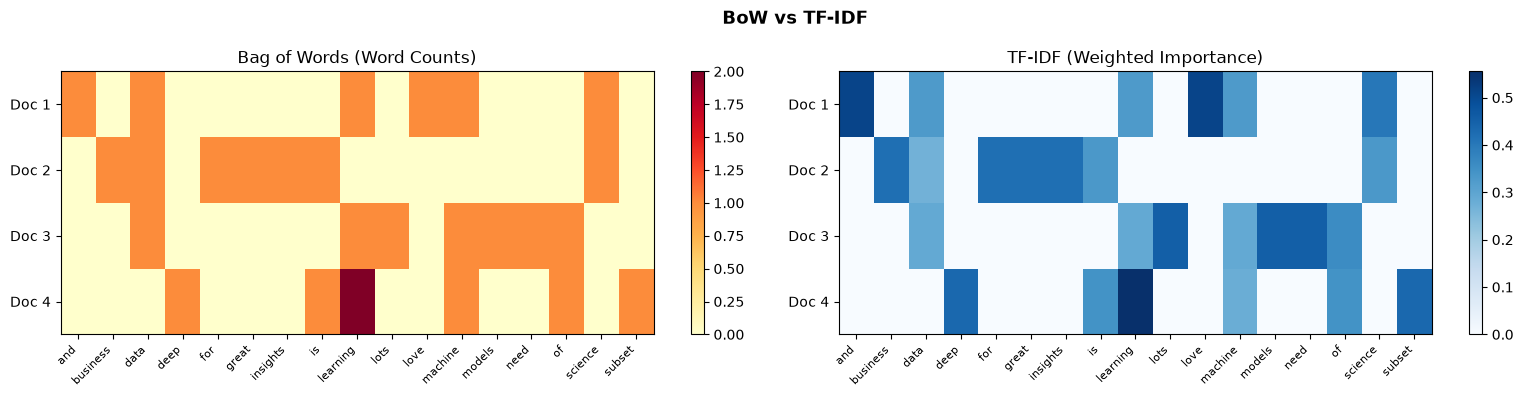

In [4]:
# Visualize TF-IDF heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

im1 = axes[0].imshow(bow.toarray(), cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(cv.get_feature_names_out())))
axes[0].set_xticklabels(cv.get_feature_names_out(), rotation=45, ha='right', fontsize=8)
axes[0].set_title('Bag of Words (Word Counts)')
axes[0].set_yticks(range(4)); axes[0].set_yticklabels([f'Doc {i+1}' for i in range(4)])
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(tf.toarray(), cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(tfidf.get_feature_names_out())))
axes[1].set_xticklabels(tfidf.get_feature_names_out(), rotation=45, ha='right', fontsize=8)
axes[1].set_title('TF-IDF (Weighted Importance)')
axes[1].set_yticks(range(4)); axes[1].set_yticklabels([f'Doc {i+1}' for i in range(4)])
plt.colorbar(im2, ax=axes[1])

plt.suptitle('BoW vs TF-IDF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/bow_tfidf.png', dpi=100)
plt.show()

## 3. Sentiment Analysis — Real Dataset

In [5]:
# Movie review dataset
np.random.seed(42)
positive_reviews = [
    'This movie was absolutely fantastic and amazing',
    'I loved every minute of this brilliant film',
    'Outstanding performances and wonderful storyline',
    'A masterpiece that I highly recommend to everyone',
    'Beautiful cinematography and excellent direction',
    'The best movie I have seen this year truly great',
    'Incredible acting superb visuals loved it',
    'A feel good movie with great humor and charm',
    'Wonderful experience heartwarming and inspiring',
    'Perfect storytelling brilliant cast enjoyed it',
] * 30

negative_reviews = [
    'This movie was terrible and boring waste of time',
    'Worst film I have ever seen completely awful',
    'Poor acting bad script total disappointment',
    'Extremely disappointing nothing good at all',
    'Boring plot weak characters dull and lifeless',
    'A complete disaster avoid this at all costs',
    'Terrible script bad acting poor production',
    'Complete waste of money very bad experience',
    'Dull boring not entertaining at all horrible',
    'Awful film no redeeming qualities whatsoever bad',
] * 30

# Add variation
np.random.shuffle(positive_reviews)
np.random.shuffle(negative_reviews)

reviews = positive_reviews[:200] + negative_reviews[:200]
labels  = ['positive'] * 200 + ['negative'] * 200

X_tr, X_te, y_tr, y_te = train_test_split(reviews, labels, test_size=0.2, random_state=42)

# Pipeline: TF-IDF + Logistic Regression
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=500, min_df=2)),
    ('clf',   LogisticRegression(max_iter=1000))
])
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

print('Sentiment Analysis Results:')
print(classification_report(y_te, y_pred))

# Test on new reviews
new_reviews = [
    'This film was absolutely amazing loved it',
    'Terrible waste of time boring and awful'
]
for review in new_reviews:
    sentiment = pipe.predict([review])[0]
    prob = pipe.predict_proba([review])[0]
    print(f'  "{review[:50]}..." -> {sentiment} ({max(prob):.0%} confident)')

Sentiment Analysis Results:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        36
    positive       1.00      1.00      1.00        44

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

  "This film was absolutely amazing loved it..." -> positive (84% confident)
  "Terrible waste of time boring and awful..." -> negative (90% confident)


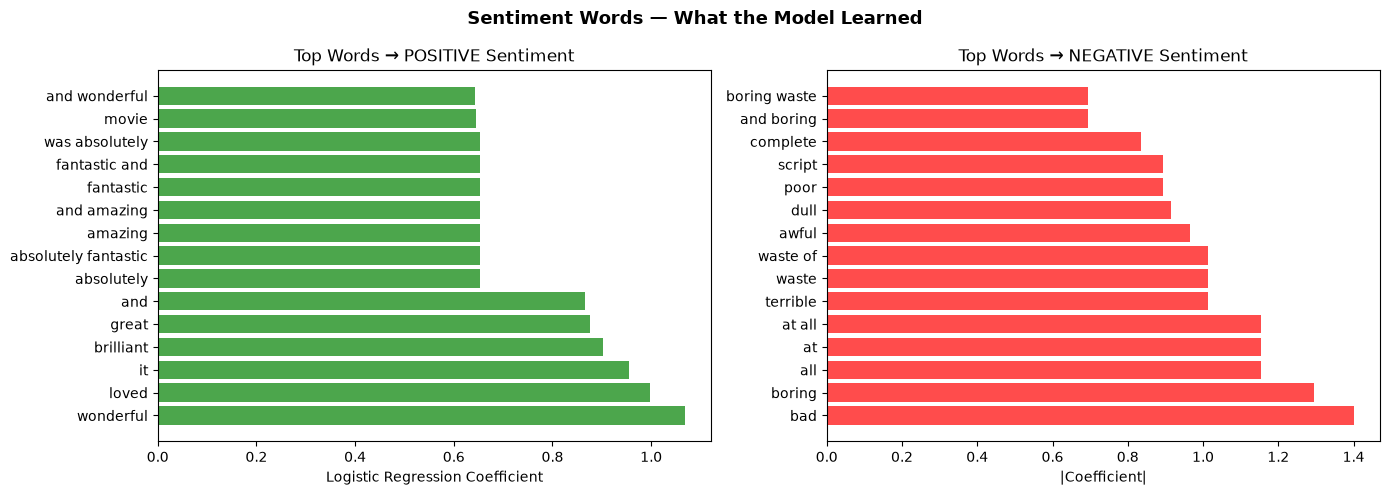

In [6]:
# Visualize most important words
tfidf_fitted = pipe.named_steps['tfidf']
clf_fitted   = pipe.named_steps['clf']

vocab = tfidf_fitted.get_feature_names_out()
coefs = clf_fitted.coef_[0]

top_pos = pd.Series(coefs, index=vocab).nlargest(15)
top_neg = pd.Series(coefs, index=vocab).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_pos.index, top_pos.values, color='green', alpha=0.7)
axes[0].set_title('Top Words → POSITIVE Sentiment')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(top_neg.index, np.abs(top_neg.values), color='red', alpha=0.7)
axes[1].set_title('Top Words → NEGATIVE Sentiment')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Sentiment Words — What the Model Learned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/sentiment_words.png', dpi=100)
plt.show()

## 4. Topic Modeling — LDA

In [7]:
from sklearn.decomposition import LatentDirichletAllocation

# Create multi-topic corpus
topics_corpus = [
    # Sports
    'football player scored goal championship match team tournament',
    'cricket team won match batting bowling stadium wicket',
    'tennis player tournament wimbledon grand slam court serve',
    # Technology
    'artificial intelligence machine learning deep neural network algorithm',
    'python programming code software developer application database',
    'smartphone battery processor camera screen mobile app technology',
    # Health
    'hospital doctor patient medicine treatment health disease virus',
    'exercise fitness gym diet nutrition calories weight healthy',
    'vaccine immune system antibody clinical trial research drug',
] * 15

tfidf_lda = TfidfVectorizer(max_features=200, min_df=2, max_df=0.85)
X_lda = tfidf_lda.fit_transform(topics_corpus)

lda = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=20)
lda.fit(X_lda)

feature_names = tfidf_lda.get_feature_names_out()
print('Discovered Topics:')
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f'  Topic {topic_idx+1}: {", ".join(top_words)}')

Discovered Topics:
  Topic 1: football, championship, goal, scored, developer, programming, software, python, database, code
  Topic 2: won, stadium, cricket, batting, bowling, wicket, vaccine, system, antibody, research
  Topic 3: grand, slam, wimbledon, court, tennis, serve, hospital, doctor, disease, patient


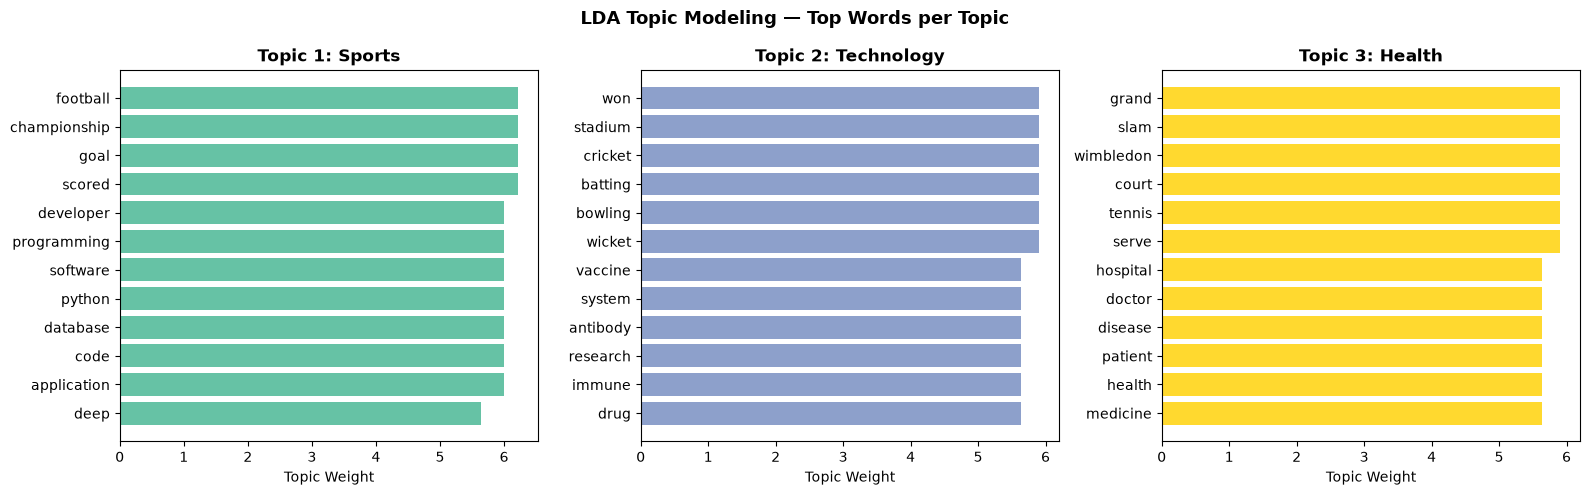

In [8]:
# Visualize topics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
topic_labels = ['Topic 1: Sports', 'Topic 2: Technology', 'Topic 3: Health']

for i, (ax, label) in enumerate(zip(axes, topic_labels)):
    top_idx   = lda.components_[i].argsort()[-12:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_wts   = lda.components_[i][top_idx]
    
    ax.barh(top_words[::-1], top_wts[::-1], color=plt.cm.Set2(i/3))
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Topic Weight')

plt.suptitle('LDA Topic Modeling — Top Words per Topic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/lda_topics.png', dpi=100)
plt.show()

## 5. Text Classification Comparison

In [9]:
# Compare classifiers on text data
classifiers = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM'         : LinearSVC(max_iter=2000),
}

all_reviews = positive_reviews[:200] + negative_reviews[:200]
all_labels  = ['positive']*200 + ['negative']*200

vec = TfidfVectorizer(ngram_range=(1,2), max_features=1000)
X_vec = vec.fit_transform(all_reviews).toarray()
y_labels = np.array(all_labels)

print(f'{'Model':<25} {'CV Accuracy':>12} {'Std':>8}')
print('-' * 45)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_vec, y_labels, cv=5, scoring='accuracy')
    print(f'{name:<25} {scores.mean():>12.2%} {scores.std():>8.3f}')

Model                      CV Accuracy      Std
---------------------------------------------
Naive Bayes                    100.00%    0.000
Logistic Regression            100.00%    0.000
Linear SVM                     100.00%    0.000


## Summary

| Step | Tools |
|---|---|
| Preprocessing | regex, tokenize, stopwords, stemming |
| Vectorization | CountVectorizer, TF-IDF |
| Sentiment | TF-IDF + Logistic Regression |
| Classification | Naive Bayes, SVM (great for text!) |
| Topic Modeling | LDA |
| Advanced | BERT, transformers (next level) |

**Next notebook →** `18_End_to_End_ML_Project.ipynb`